# Assignment 4

assumptions: isothermal, heat of reaction negligible -> only mass balance considered, rate constant not temperature dependent

\begin{align*}
    A \rightarrow B
\end{align*}

mass balance:

\begin{align*}
    \frac{dc_A}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_B}{d\tau}=r
\end{align*}

first order:

r = k*c_A

\begin{align*}
    r=-\frac{dc_A}{d\tau}=-u\frac{dc_A}{dz}=k \cdot c_A
\end{align*}

\begin{align*}
    r=-\frac{dc_B}{d\tau}=u\frac{dc_B}{dz}
\end{align*}

## Implementation

In [11]:
import sys
import numpy as np
import scipy
import scipy.integrate as integ #important for initial value problem
from scipy.integrate import solve_ivp
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

### Initial value problem

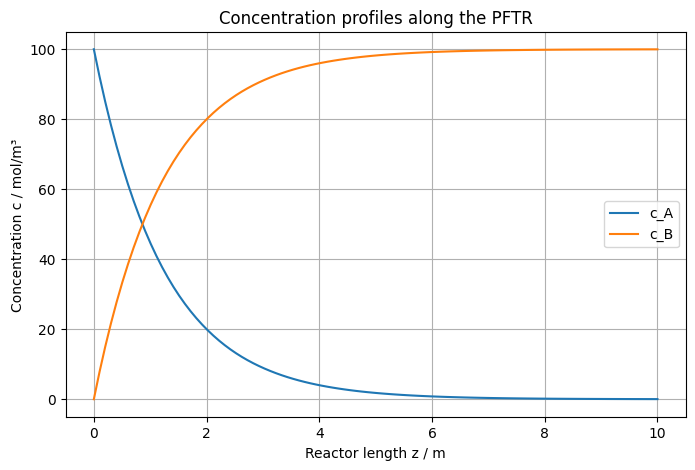

In [12]:
#implement parameters

L = 10 #reactor length / m
d = 32 *10**-3 #reactor diameter / m
d_up = 150 * 10**(-3) # diameter upstream / m
V_dot = 1 # volumetric flow rate / m3/s
c_A_in = 100 # inlet concentration of component A / mol/m3
k = 1*10**3 # reaction rate constant / m3/mol/s

u = V_dot / (np.pi * (d/2)**2) # superficial velocity / m/s

def kinetics(c_A):
    r=k*c_A # reaction rate / mol/m3/s
    return r
    
def PFTR(z, f):
    'Function for component balance and energy balance'
    # f is a vector containing concentrations of components c_A (f[0]) and c_B (f[1])
    c_A = f[0]
    c_B = f[1]
    
    # reaction rate from kinetics function
    r = kinetics(c_A)
    
    # differential equations
    dc_A_dz = -r/u #change in concentration of B along the reactor length / mol/m^3/m
    dc_B_dz = r/u #change in concentration of C along the reactor length / mol/m^3/m
    
    dfdz = np.empty_like(f)
    dfdz[0] = dc_A_dz
    dfdz[1] = dc_B_dz
    return dfdz

# vector of initial conditions
f_init = np.array([c_A_in, 0]) #initial concentrations of A and B

# solve the system of ODEs using scipy's solve_ivp
tspan = (0, L) #span of the reactor length
teval = np.linspace(0, L, 100) #points at which to evaluate the solution
sol = integ.solve_ivp(PFTR, tspan, f_init, t_eval=teval)

# Plot concentration c over reactor length z

plt.figure(figsize=(8, 5))

plt.plot(sol.t, sol.y[0], label='c_A')
plt.plot(sol.t, sol.y[1], label='c_B')

plt.xlabel('Reactor length z / m')
plt.ylabel('Concentration c / mol/m³')
plt.title('Concentration profiles along the PFTR')
plt.grid(True)
plt.legend()
plt.show()

### Boundary Value Problem

$$
u \frac{\text{d}c_i}{\text{d}z} = \mathcal{D} \frac{\text{d}^2 c_i }{\text{d} z^2} + \sum_{j=1}^{M} \nu_{i,j} r_j
$$

boundary case D=0 ideal PFTR model
higher dispersion coefficient, wider residence time distribution

Bodenstein-Number, convective mass transfer compared to backmixing

$$
Bo = \frac{u \, L}{\mathcal{D}}
$$
